# Comparision between different filters for blue light experiment

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os

expFolder = "data2_10Jun26"
base = Path.home() / "projects" / "metamers" / "hueSensor" / expFolder
files = os.listdir(base)
print(files)

['blue-red_NF.txt', 'blue-fixed_B.txt', 'blue-yellow_Y.txt', 'blue_B.txt', 'blue-fixed_O.txt', 'blue_O.txt', 'blue-red_O.txt', 'blue-red_Y.txt', 'blue-yellow_O.txt', 'blue_Y.txt', 'blue-red_R.txt', 'blue-yellow_C.txt', 'blue-fixed_R.txt', 'blue-yellow_NF.txt', 'blue-red_B.txt', 'blue_R.txt', 'blue_NF.txt', 'blue-yellow_B.txt', 'blue-fixed_Y.txt', 'blue-red_C.txt', 'blue_C.txt', 'blue-fixed_NF.txt', 'blue-yellow_R.txt', 'blue-fixed_C.txt']


In [2]:

base = Path(base)

FILTER_COLORS = {
    "NF": "black",
    "C": "cyan",
    "B": "blue",
    "R": "red",
    "Y": "yellow",
    "O": "orange",
}
FILTER_ORDER = ["NF", "B", "C", "R", "Y", "O"]

def parse_filename(fname):
    name = fname.replace(".txt", "")
    condition, filt = name.split("_")
    return condition, filt

def load_all_data(base):
    data = {}

    for fname in os.listdir(base):
        if not fname.endswith(".txt"):
            continue

        condition, filt = parse_filename(fname)

        # Load full file
        df = pd.read_csv(base / fname, sep="\t", header=0)

        # Extract only R, G, B columns
        rgb = df[["R", "G", "B"]].copy()

        if condition not in data:
            data[condition] = {}

        data[condition][filt] = rgb

    return data

def sort_filters(filters):
    return sorted(filters, key=lambda f: FILTER_ORDER.index(f))


def plot_rgb_per_filter(data):
    conditions = list(data.keys())

    # Sort filters using your canonical order
    all_filters = sort_filters({f for cond in data.values() for f in cond.keys()})

    n_rows = len(conditions)
    n_cols = len(all_filters)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows), sharex=True)

    if n_rows == 1:
        axes = axes.reshape(1, n_cols)

    for i, cond in enumerate(conditions):

        # Compute row-wise y-limits
        row_min, row_max = np.inf, -np.inf
        for filt, df in data[cond].items():
            row_min = min(row_min, df[["R","G","B"]].min().min())
            row_max = max(row_max, df[["R","G","B"]].max().max())

        for j, filt in enumerate(all_filters):
            ax = axes[i, j]

            if filt in data[cond]:
                df = data[cond][filt]

                ax.plot(df["R"], color="red")
                ax.plot(df["G"], color="green")
                ax.plot(df["B"], color="blue")

                ax.set_ylim(row_min, row_max)
                ax.set_title(f"{cond} — {filt}")
            else:
                ax.set_visible(False)

            if j == 0:
                ax.set_ylabel("Value")

    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")

    plt.tight_layout()
    plt.show()

def plot_filters_by_channel(data, filter_colors):
    conditions = list(data.keys())
    n = len(conditions)

    fig, axes = plt.subplots(n, 3, figsize=(12, 3*n), sharex=True)

    if n == 1:
        axes = axes.reshape(1, 3)

    for i, cond in enumerate(conditions):

        # --- Compute row-wise y-limits (all filters, all channels) ---
        row_min, row_max = np.inf, -np.inf
        for filt, df in data[cond].items():
            row_min = min(row_min, df[["R","G","B"]].min().min())
            row_max = max(row_max, df[["R","G","B"]].max().max())

        # --- Plot each channel in its own column ---
        for j, col in enumerate(["R", "G", "B"]):
            ax = axes[i, j]

            for filt, df in data[cond].items():
                color = filter_colors.get(filt, "black")
                ax.plot(df[col], color=color, label=filt, linewidth=1.2)

            ax.set_ylim(row_min, row_max)
            ax.set_title(f"{cond} — {col}")
            if j == 0:
                ax.set_ylabel("Value")

    # One legend for the whole figure
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")

    plt.tight_layout()
    plt.show()

data = load_all_data(base)


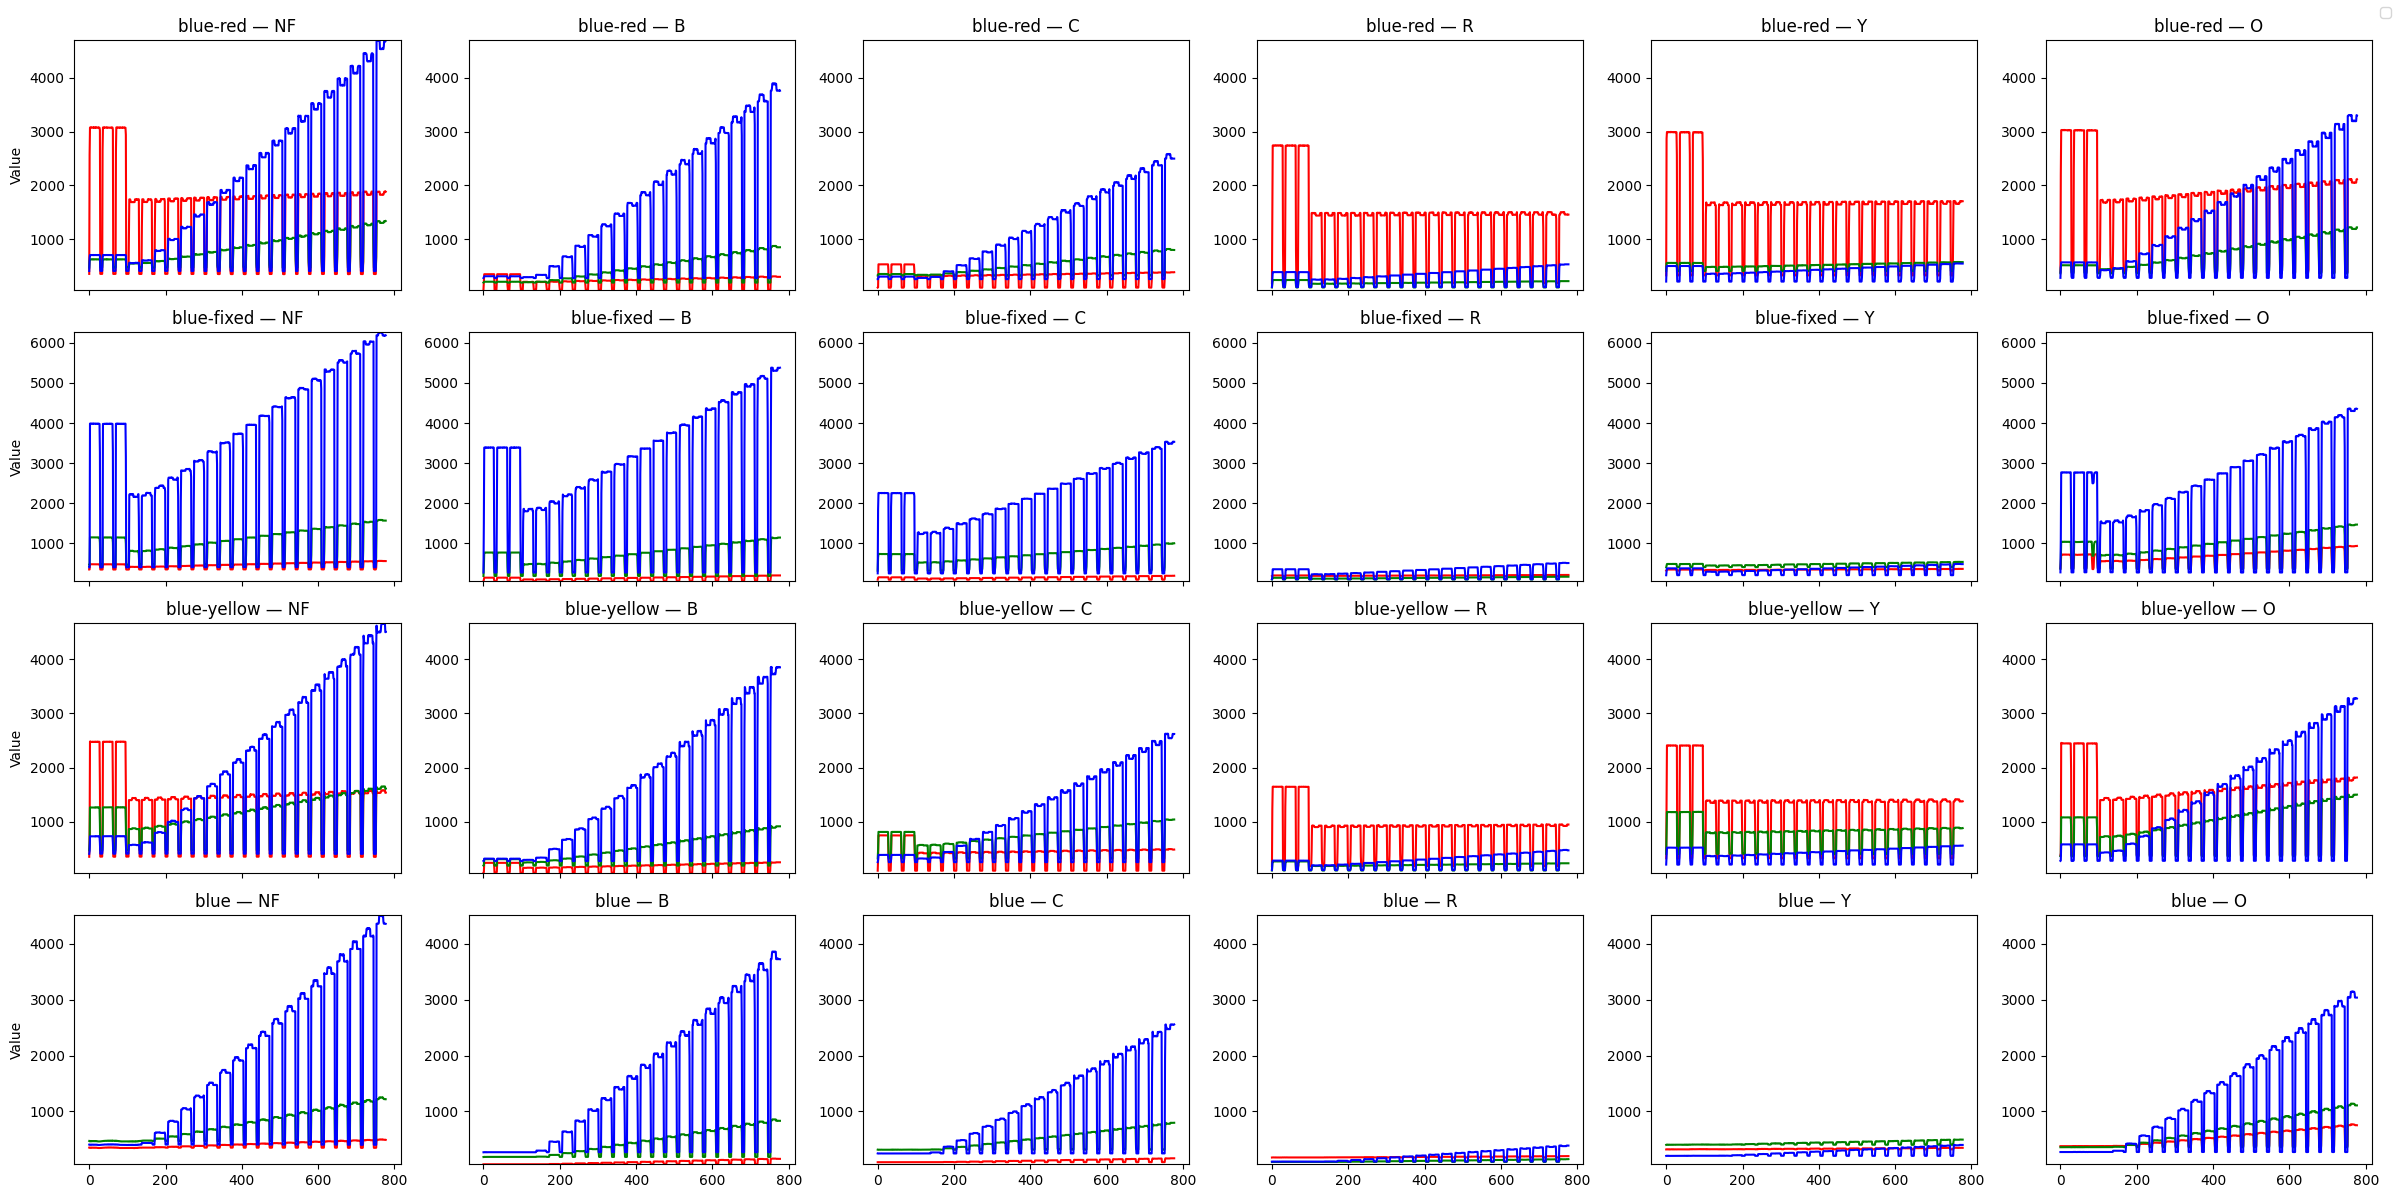

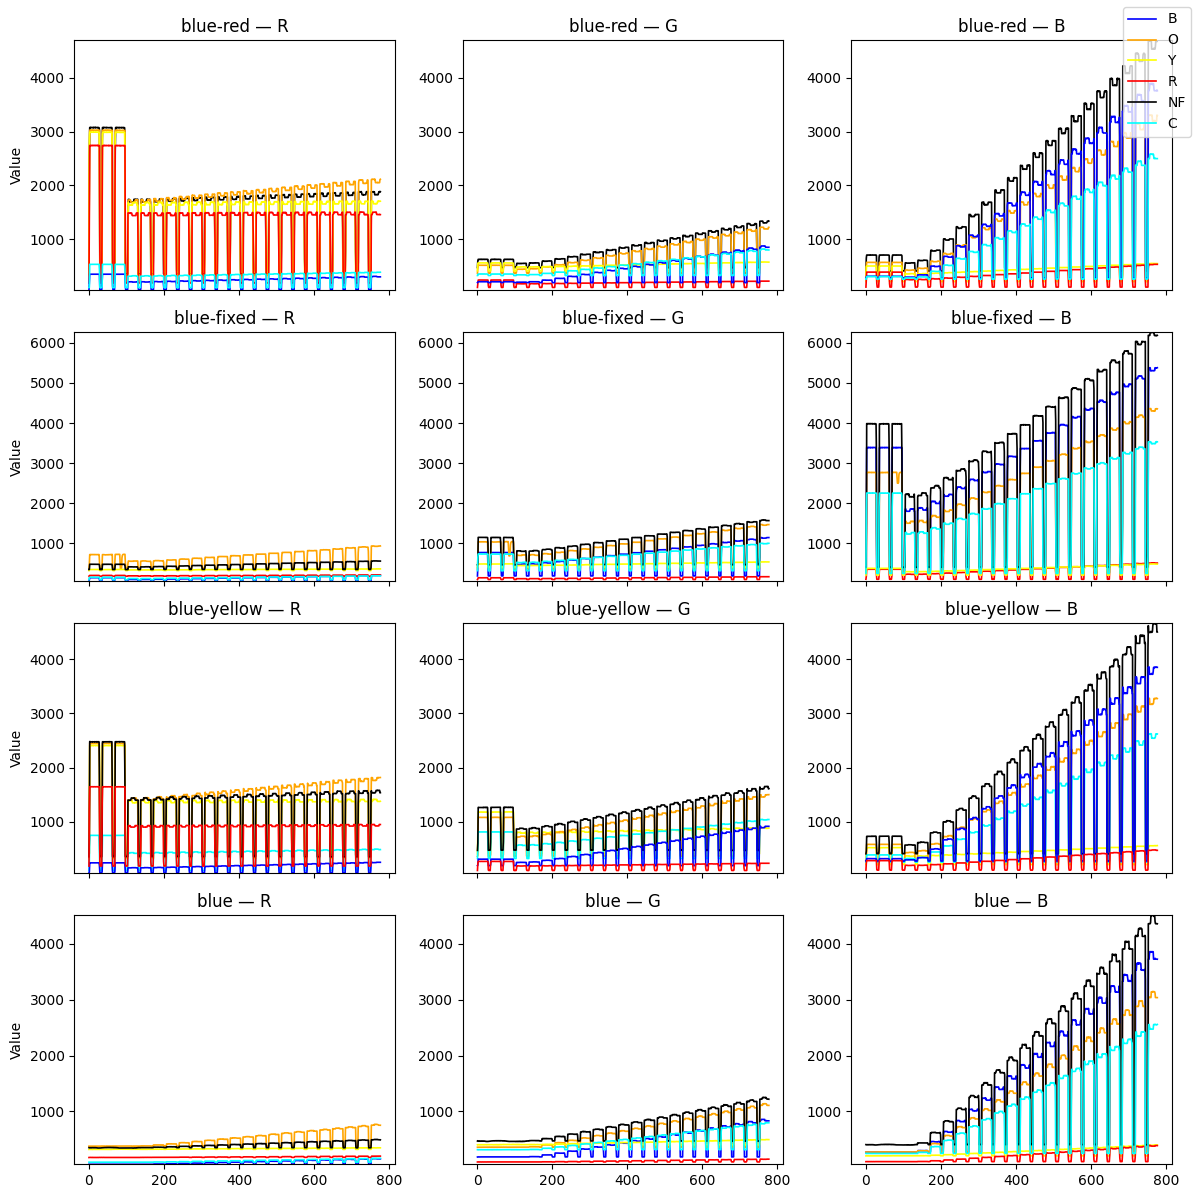

In [3]:
plot_rgb_per_filter(data)
plot_filters_by_channel(data, FILTER_COLORS)
